# 1. Import Libraries

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 2. Load Dataset

In [2]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


# 3. EDA

### Shape of training and testing data

In [4]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


### Image Display

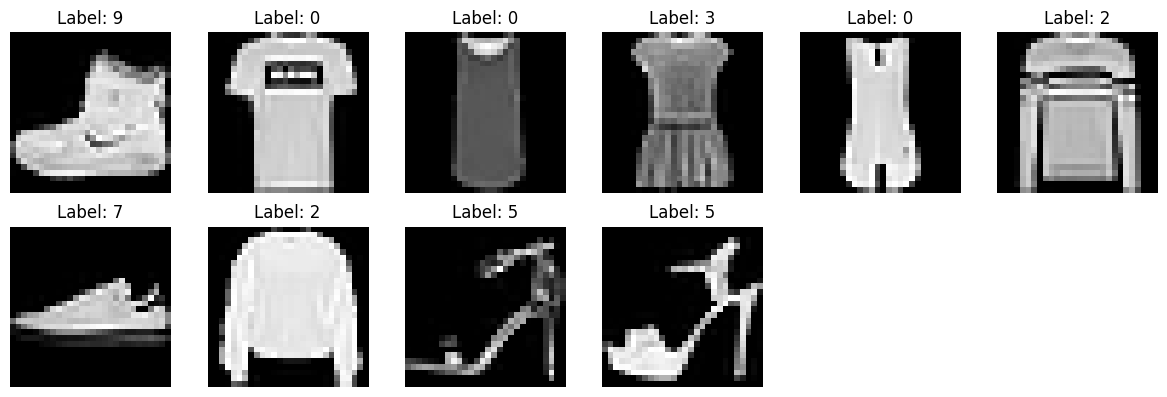

In [13]:
plt.figure(figsize=(12, 6))

for i in range(10):
    plt.subplot(3, 6, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

### Pixels range

In [15]:
print("Min Value :", X_train.min())
print("Max Value :", X_train.max())

Min Value : 0
Max Value : 255


# 4. Data Preprocessing
### Normalize

In [16]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

### Reshaping to prepare for CNN

In [17]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

### Shape Chekcing After reshaping

In [18]:
print("Training Images :", X_train.shape)
print("Testing Images :", X_test.shape)

Training Images : (60000, 28, 28, 1)
Testing Images : (10000, 28, 28, 1)


# 6. Model Training

### Model Building

In [23]:
model = Sequential([

    # 1. First Convolution Layer
    Conv2D(
        filters=32,
        kernel_size=(3,3),
        strides=(1,1),
        padding="same",
        activation="relu",
        input_shape=(28,28,1)
    ),

    MaxPooling2D(
        pool_size=(2,2)
    ),

    # 2. Second Convolution Layer
    Conv2D(
        filters=64,
        kernel_size=(3,3),
        strides=(1,1),
        padding="same",
        activation="relu"
    ),

    # 3. Pooling Layer
    MaxPooling2D(
        pool_size=(2,2)
    ),

    # 4. Flatten Layer
    Flatten(),

    # 5.Fully Connected Layers(2)
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),

    # 6. utput Layer
    Dense(10, activation="softmax")

])

### Summary

In [24]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 429,258 (1.64 MB)

 Trainable params: 429,258 (1.64 MB)

 Non-trainable params: 0 (0.00 B)

### Compile

| **Parameter** | **Common Values** |
|---------------|-------------------|
| **optimizer** | `"adam"`, `"sgd"`, `"rmsprop"`, `"adagrad"`, `"adamax"`, `"nadam"`, `"adadelta"`, `"ftrl"` |
| **loss** | `"sparse_categorical_crossentropy"`, `"categorical_crossentropy"`, `"binary_crossentropy"`, `"mse"`, `"mae"`, `"huber"` |
| **metrics** | `"accuracy"`, `"Precision()"`, `"Recall()"`, `"AUC()"`, `"TopKCategoricalAccuracy()"`, `"mse"`, `"mae"` |

In [25]:
model.compile(
    optimizer="adam",  # other optimizers and scenerios ?
    loss="sparse_categorical_crossentropy",  # other los functions with scenerio
    metrics=["accuracy"]     # use accuracy only, other metrices will check after training
)

### Train

In [26]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 84s 55ms/step - accuracy: 0.8456 - loss: 0.4281 - val_accuracy: 0.8835 - val_loss: 0.3269
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 72s 48ms/step - accuracy: 0.8966 - loss: 0.2816 - val_accuracy: 0.8995 - val_loss: 0.2759
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 64s 42ms/step - accuracy: 0.9123 - loss: 0.2371 - val_accuracy: 0.8988 - val_loss: 0.2867
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 82s 42ms/step - accuracy: 0.9246 - loss: 0.2040 - val_accuracy: 0.9108 - val_loss: 0.2466
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 87s 46ms/step - accuracy: 0.9350 - loss: 0.1759 - val_accuracy: 0.9128 - val_loss: 0.2446
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 80s 44ms/step - accuracy: 0.9429 - loss: 0.1538 - val_accuracy: 0.9185 - val_loss: 0.2324
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 80s 43ms/step - accuracy: 0.9509 - loss: 0.1317 - val_accuracy: 0.9135 - val_loss: 0.2557
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 82s 42ms/step - accuracy: 0.9585 -

# 7. Predictions

In [34]:
predictions = model.predict(X_test)

# Convert probabilities to class labels
predicted_labels = np.argmax(predictions, axis=1)

print(predicted_labels[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step
[9 2 1 1 6 1 4 6 5 7]


# 8. Evaluation

### Check accuracy and loss

In [29]:
# Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9136 - loss: 0.3154
Test Loss: 0.3154
Test Accuracy: 0.9136


### check precision,accuracy,recall and f1 score

In [35]:
accuracy = accuracy_score(y_test, predicted_labels)
precision = precision_score(y_test, predicted_labels, average="weighted")
recall = recall_score(y_test, predicted_labels, average="weighted")
f1 = f1_score(y_test, predicted_labels, average="weighted")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.9136
Precision: 0.9144
Recall   : 0.9136
F1 Score : 0.9136


### Visual Represenatation of Confusion matrix

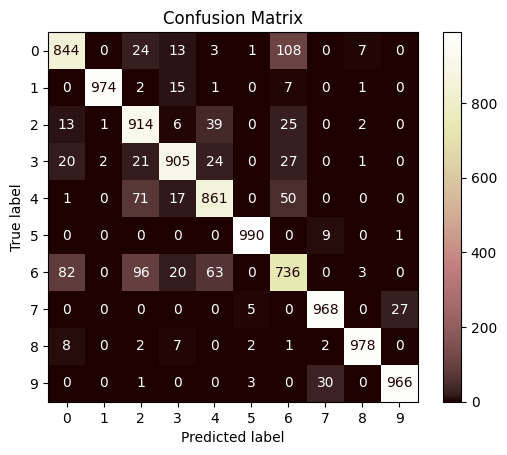

In [44]:
cm = confusion_matrix(y_test, predicted_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="pink")
plt.title("Confusion Matrix")
plt.show()

### Predicted and Actual Lables

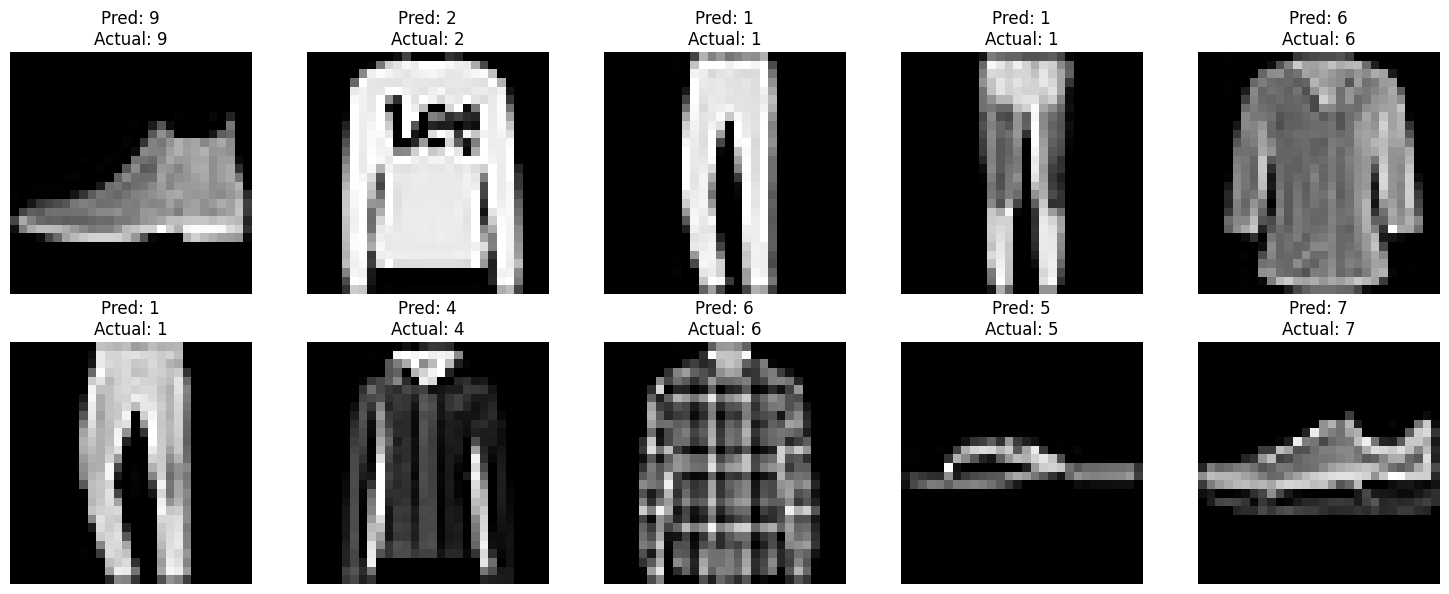

In [45]:
plt.figure(figsize=(15,6))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(X_test[i].reshape(28,28), cmap="gray")

    plt.title(f"Pred: {predicted_labels[i]}\nActual: {y_test[i]}")

    plt.axis("off")

plt.tight_layout()
plt.show()

### Training and VAlidation Accuracy Curve

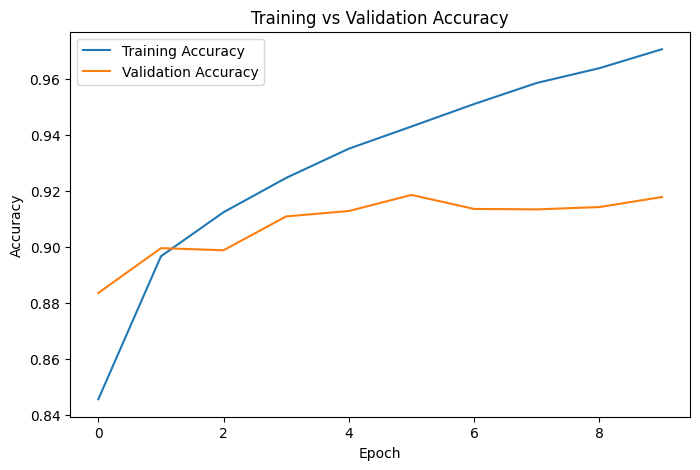

In [46]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

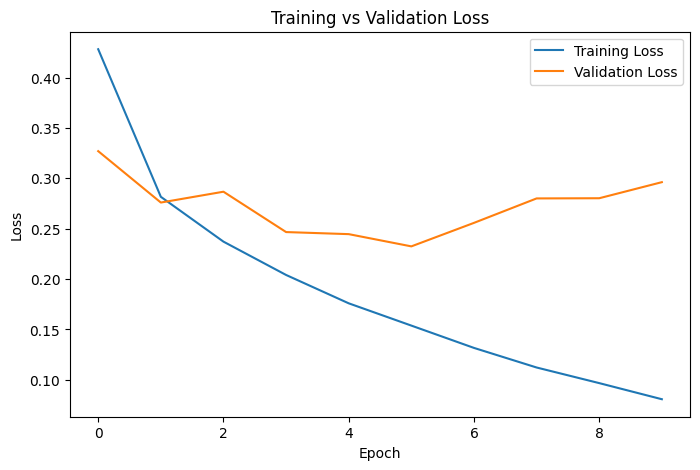

In [52]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [51]:
for epoch in range(len(history.history["accuracy"])):
    print(
        f"Epoch {epoch+1}: "
        f"Training Accuracy = {history.history['accuracy'][epoch]:.4f}, "
        f"Validation Accuracy = {history.history['val_accuracy'][epoch]:.4f}"
    )

Epoch 1: Training Accuracy = 0.8456, Validation Accuracy = 0.8835
Epoch 2: Training Accuracy = 0.8966, Validation Accuracy = 0.8995
Epoch 3: Training Accuracy = 0.9123, Validation Accuracy = 0.8988
Epoch 4: Training Accuracy = 0.9246, Validation Accuracy = 0.9108
Epoch 5: Training Accuracy = 0.9350, Validation Accuracy = 0.9128
Epoch 6: Training Accuracy = 0.9429, Validation Accuracy = 0.9185
Epoch 7: Training Accuracy = 0.9509, Validation Accuracy = 0.9135
Epoch 8: Training Accuracy = 0.9585, Validation Accuracy = 0.9133
Epoch 9: Training Accuracy = 0.9637, Validation Accuracy = 0.9142
Epoch 10: Training Accuracy = 0.9705, Validation Accuracy = 0.9178


### Correctly Classified

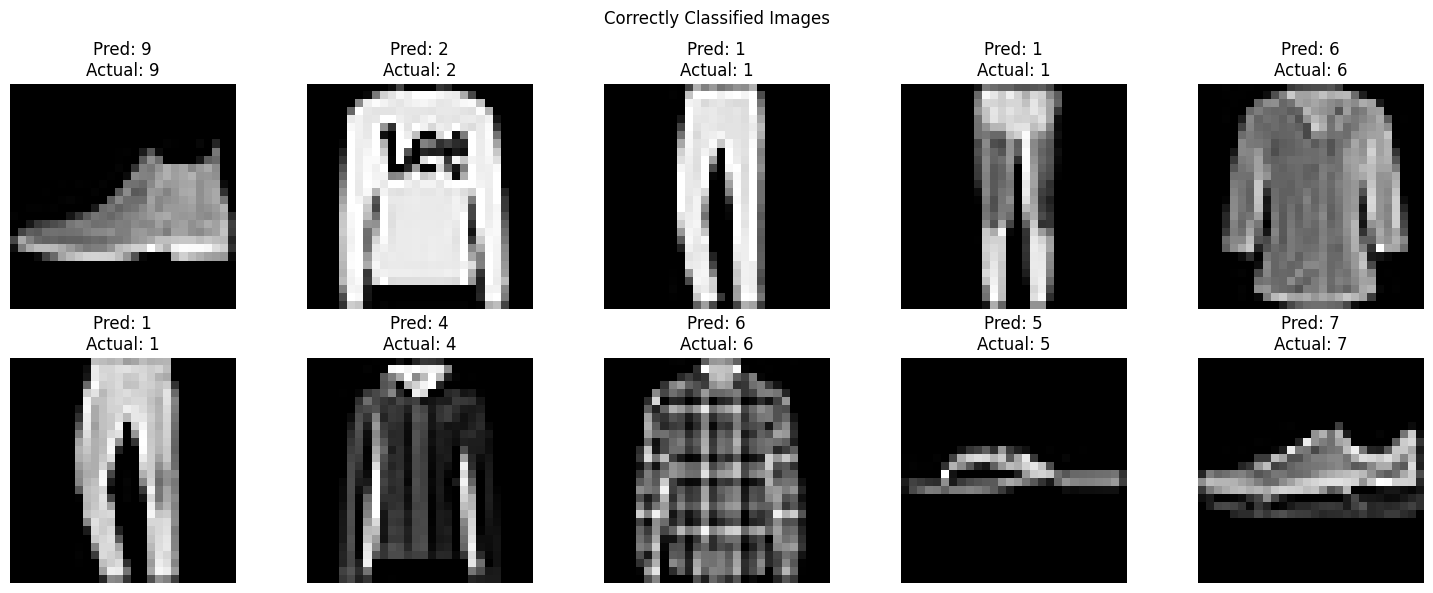

In [49]:
plt.figure(figsize=(15, 6))

count = 1

for i in range(len(y_test)):

    if predicted_labels[i] == y_test[i]:

        plt.subplot(2, 5, count)
        plt.imshow(X_test[i], cmap="gray")
        plt.title(f"Pred: {predicted_labels[i]}\nActual: {y_test[i]}")
        plt.axis("off")
        count += 1
        if count > 10:
            break

plt.suptitle("Correctly Classified Images")
plt.tight_layout()
plt.show()

### incorrectly Classified

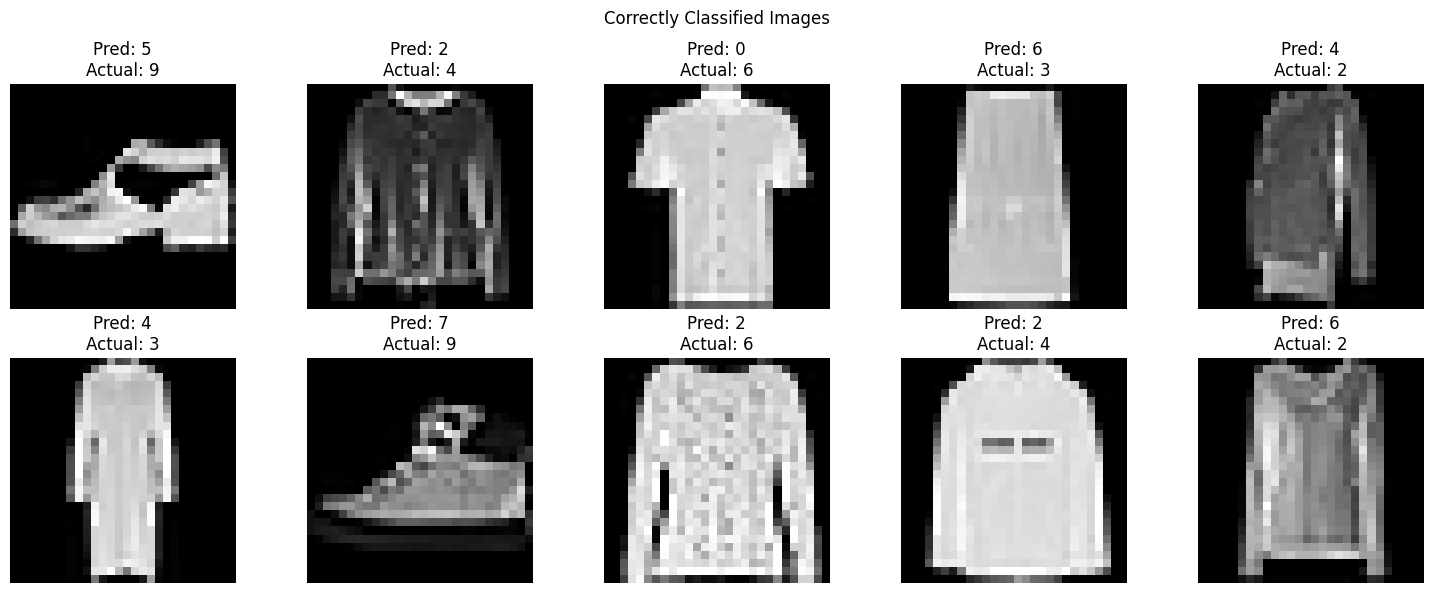

In [50]:
plt.figure(figsize=(15, 6))

count = 1

for i in range(len(y_test)):

    if predicted_labels[i] != y_test[i]:

        plt.subplot(2, 5, count)
        plt.imshow(X_test[i], cmap="gray")
        plt.title(f"Pred: {predicted_labels[i]}\nActual: {y_test[i]}")
        plt.axis("off")
        count += 1
        if count > 10:
            break

plt.suptitle("Correctly Classified Images")
plt.tight_layout()
plt.show()